In [1]:
# Cell 1: Environment Paths & Directory Setup
import logging
from pathlib import Path

# Setup Google Drive mount if running in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    has_colab = True
except Exception:
    has_colab = False

# Path Resolution
DEFAULT_COLAB_ROOT = Path("/content/drive/MyDrive/MPLADs")
ALT_COLAB_ROOT = Path("/content/drive/MYDrive/MPLADs")

if has_colab and DEFAULT_COLAB_ROOT.exists():
    PROJECT_ROOT = DEFAULT_COLAB_ROOT
elif has_colab and ALT_COLAB_ROOT.exists():
    PROJECT_ROOT = ALT_COLAB_ROOT
elif (Path.cwd() / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

SHARED_ARTIFACT_DIR = PROJECT_ROOT / "shared_preprocessing_artifacts"
FEATURE3_ARTIFACT_DIR = PROJECT_ROOT / "feature3_artifacts"
OUTPUT_DIR = PROJECT_ROOT / "feature1_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("mplads_feature1")

logger.info("Project Root: %s", PROJECT_ROOT)
logger.info("Shared Artifacts Dir: %s", SHARED_ARTIFACT_DIR)
logger.info("Feature 3 Artifacts Dir: %s", FEATURE3_ARTIFACT_DIR)
logger.info("Feature 1 Output Dir: %s", OUTPUT_DIR)


Mounted at /content/drive


In [2]:
# Cell 2: Data Ingestion & Schema Integrity Validation
import pandas as pd
import numpy as np

def read_artifact(dir_path: Path, name: str) -> pd.DataFrame:
    """Reads parquet artifact if available, falling back to CSV."""
    parquet_path = dir_path / f"{name}.parquet"
    csv_path = dir_path / f"{name}.csv"

    if parquet_path.exists():
        try:
            logger.info("Loading parquet: %s", parquet_path)
            return pd.read_parquet(parquet_path)
        except Exception as e:
            logger.warning("Failed loading parquet %s (%s). Falling back to CSV.", parquet_path, e)

    if csv_path.exists():
        logger.info("Loading CSV: %s", csv_path)
        return pd.read_csv(csv_path, low_memory=False)

    raise FileNotFoundError(f"Could not find {name}.parquet or {name}.csv in {dir_path}")

# Load inputs
try:
    fact_work_enriched = read_artifact(FEATURE3_ARTIFACT_DIR, "feature3_fact_work_enriched")
except Exception:
    logger.info("Enriched table not found in feature3_artifacts, checking shared_preprocessing_artifacts...")
    fact_work_enriched = read_artifact(SHARED_ARTIFACT_DIR, "fact_work")

fact_expenditure_rollup = read_artifact(SHARED_ARTIFACT_DIR, "fact_expenditure_rollup")

logger.info("Loaded fact_work shape: %s", fact_work_enriched.shape)
logger.info("Loaded fact_expenditure_rollup shape: %s", fact_expenditure_rollup.shape)

if "work_key" not in fact_work_enriched.columns:
    raise KeyError("Missing required key column 'work_key' in fact_work.")

fe_cols = [
    "work_key", "total_fund_disbursed", "vendor_tranche_count",
    "n_vendors", "first_expenditure_date", "last_expenditure_date",
    "any_success", "any_in_progress"
]
fe_sub = fact_expenditure_rollup[[c for c in fe_cols if c in fact_expenditure_rollup.columns]].drop_duplicates(subset=["work_key"])

# Merge Work Fact with Expenditure Rollup
work_df = fact_work_enriched.merge(fe_sub, on="work_key", how="left", suffixes=("", "_exp"))
logger.info("Merged dataset shape: %s", work_df.shape)


In [3]:
# Disbursement Shortfall & Coverage Calculation
df = work_df.copy()

df["sanction_amount"] = pd.to_numeric(df["sanction_amount"], errors="coerce")
df["amount_disbursed"] = pd.to_numeric(df["amount_disbursed"], errors="coerce")

if "total_fund_disbursed" in df.columns:
    df["total_fund_disbursed"] = pd.to_numeric(df["total_fund_disbursed"], errors="coerce")
else:
    df["total_fund_disbursed"] = np.nan

df["final_disbursed"] = np.where(df["amount_disbursed"].notna() & (df["amount_disbursed"] > 0), df["amount_disbursed"], np.nan)
df["tranche_sum_disbursed"] = np.where(df["total_fund_disbursed"].notna() & (df["total_fund_disbursed"] > 0), df["total_fund_disbursed"], np.nan)

df["has_final_disbursement"] = df["final_disbursed"].notna()
df["has_tranche_disbursement"] = df["tranche_sum_disbursed"].notna()

df["coverage_flag"] = np.where(
    df["has_final_disbursement"],
    "linked_final",
    np.where(df["has_tranche_disbursement"], "linked_tranche", "disbursement_unknown")
)

df["shortfall_source"] = np.where(
    df["has_final_disbursement"] & df["has_tranche_disbursement"],
    "both",
    np.where(
        df["has_final_disbursement"],
        "final",
        np.where(df["has_tranche_disbursement"], "tranche", "unknown")
    )
)

valid_sanct = df["sanction_amount"].notna() & (df["sanction_amount"] > 0)

df["shortfall_pct_final"] = np.where(
    valid_sanct & df["has_final_disbursement"],
    (df["final_disbursed"] - df["sanction_amount"]) / df["sanction_amount"],
    np.nan
)

df["shortfall_pct_tranche"] = np.where(
    valid_sanct & df["has_tranche_disbursement"],
    (df["tranche_sum_disbursed"] - df["sanction_amount"]) / df["sanction_amount"],
    np.nan
)

df["shortfall_deficit_pct_final"] = np.where(
    df["shortfall_pct_final"].notna(),
    np.maximum(0.0, -df["shortfall_pct_final"] * 100.0),
    np.nan
)

df["shortfall_deficit_pct_tranche"] = np.where(
    df["shortfall_pct_tranche"].notna(),
    np.maximum(0.0, -df["shortfall_pct_tranche"] * 100.0),
    np.nan
)

# NOTE: effective_disbursed is maintained strictly for display compatibility.
# It is NOT used in any model feature, peer statistic, threshold, or downstream aggregate.
df["effective_disbursed"] = df["final_disbursed"].fillna(df["tranche_sum_disbursed"])
df["shortfall_deficit_pct"] = df["shortfall_deficit_pct_final"].fillna(df["shortfall_deficit_pct_tranche"])

logger.info("Coverage distribution:\n%s", df["coverage_flag"].value_counts())
logger.info("Shortfall sources distribution:\n%s", df["shortfall_source"].value_counts())


In [4]:
# Peer-Group Robust Statistical Anomaly Scoring (Fitted on Training Partition Only)
df["state_key_clean"] = df["state_key"].fillna("UNKNOWN_STATE")
df["category_nlp_clean"] = df["category_nlp"].fillna("Unclassified")
df["peer_group_key_state_cat"] = df["state_key_clean"] + " | " + df["category_nlp_clean"]
df["peer_group_key_nat_cat"] = df["category_nlp_clean"]

train_mask = (df["model_split"] == "training") & valid_sanct
train_df = df[train_mask].copy()

def calc_peer_stats_train(df_in, target_col):
    valid = df_in[df_in[target_col].notna()]
    p_stat = valid.groupby("peer_group_key_state_cat")[target_col].agg(
        peer_count="count",
        peer_median="median",
        peer_mad=lambda x: np.median(np.abs(x - np.median(x)))
    ).reset_index()
    c_stat = valid.groupby("peer_group_key_nat_cat")[target_col].agg(
        cat_count="count",
        cat_median="median",
        cat_mad=lambda x: np.median(np.abs(x - np.median(x)))
    ).reset_index()
    return p_stat, c_stat

p_stat_final, c_stat_final = calc_peer_stats_train(train_df, "shortfall_pct_final")
p_stat_tranche, c_stat_tranche = calc_peer_stats_train(train_df, "shortfall_pct_tranche")

df = df.merge(p_stat_final.rename(columns={"peer_count": "p_cnt_f", "peer_median": "p_med_f", "peer_mad": "p_mad_f"}), on="peer_group_key_state_cat", how="left")
df = df.merge(c_stat_final.rename(columns={"cat_count": "c_cnt_f", "cat_median": "c_med_f", "cat_mad": "c_mad_f"}), on="peer_group_key_nat_cat", how="left")
df = df.merge(p_stat_tranche.rename(columns={"peer_count": "p_cnt_t", "peer_median": "p_med_t", "peer_mad": "p_mad_t"}), on="peer_group_key_state_cat", how="left")
df = df.merge(c_stat_tranche.rename(columns={"cat_count": "c_cnt_t", "cat_median": "c_med_t", "cat_mad": "c_mad_t"}), on="peer_group_key_nat_cat", how="left")

category_conf = df.get("category_confidence", df.get("category_nlp_confidence", pd.Series(1.0, index=df.index)))
STABILITY_THRESHOLD = 2.0 / 3.0
usable_cat_f1 = (df.get("category_stability", pd.Series(1.0, index=df.index)) >= STABILITY_THRESHOLD) & (~df.get("category_is_noise", pd.Series(False, index=df.index)).fillna(False)) & (category_conf >= 0.55)

df["peer_reference_version"] = "v2.1_training_partition_source_aware"

# Select the reference independently for final and tranche observations. This is
# essential when a row has tranche totals but no final-file disbursement value.
def choose_peer_level(peer_count, category_count):
    return np.where(
        usable_cat_f1 & (peer_count.fillna(0) >= 10), "state_category",
        np.where(category_count.fillna(0) >= 30, "category_national", "global")
    )

df["peer_reference_level_final"] = choose_peer_level(df["p_cnt_f"], df["c_cnt_f"])
df["peer_reference_level_tranche"] = choose_peer_level(df["p_cnt_t"], df["c_cnt_t"])

train_final = train_df["shortfall_pct_final"].dropna()
train_tranche = train_df["shortfall_pct_tranche"].dropna()
global_med_f = float(train_final.median()) if not train_final.empty else 0.0
global_mad_f = float(np.median(np.abs(train_final - global_med_f))) if not train_final.empty else 0.02
global_med_t = float(train_tranche.median()) if not train_tranche.empty else 0.0
global_mad_t = float(np.median(np.abs(train_tranche - global_med_t))) if not train_tranche.empty else 0.02
global_count_f = int(train_final.shape[0])
global_count_t = int(train_tranche.shape[0])

df["peer_reference_count_final"] = np.select(
    [df["peer_reference_level_final"].eq("state_category"), df["peer_reference_level_final"].eq("category_national")],
    [df["p_cnt_f"].fillna(0), df["c_cnt_f"].fillna(0)],
    default=global_count_f
)
df["peer_reference_count_tranche"] = np.select(
    [df["peer_reference_level_tranche"].eq("state_category"), df["peer_reference_level_tranche"].eq("category_national")],
    [df["p_cnt_t"].fillna(0), df["c_cnt_t"].fillna(0)],
    default=global_count_t
)

eff_med_f = np.select(
    [df["peer_reference_level_final"].eq("state_category"), df["peer_reference_level_final"].eq("category_national")],
    [df["p_med_f"], df["c_med_f"]],
    default=global_med_f
)
eff_mad_f = np.select(
    [df["peer_reference_level_final"].eq("state_category"), df["peer_reference_level_final"].eq("category_national")],
    [df["p_mad_f"], df["c_mad_f"]],
    default=global_mad_f
)
mad_den_f = np.maximum(1.4826 * np.nan_to_num(eff_mad_f, nan=0.02), 0.02)
df["peer_shortfall_zscore_final"] = np.where(df["shortfall_pct_final"].notna(), np.maximum(0.0, (eff_med_f - df["shortfall_pct_final"]) / mad_den_f), np.nan)

eff_med_t = np.select(
    [df["peer_reference_level_tranche"].eq("state_category"), df["peer_reference_level_tranche"].eq("category_national")],
    [df["p_med_t"], df["c_med_t"]],
    default=global_med_t
)
eff_mad_t = np.select(
    [df["peer_reference_level_tranche"].eq("state_category"), df["peer_reference_level_tranche"].eq("category_national")],
    [df["p_mad_t"], df["c_mad_t"]],
    default=global_mad_t
)
mad_den_t = np.maximum(1.4826 * np.nan_to_num(eff_mad_t, nan=0.02), 0.02)
df["peer_shortfall_zscore_tranche"] = np.where(df["shortfall_pct_tranche"].notna(), np.maximum(0.0, (eff_med_t - df["shortfall_pct_tranche"]) / mad_den_t), np.nan)

# Keep the legacy fields source-aware for downstream consumers. Final is the
# preferred reference when both measures exist; tranche is used otherwise.
use_final_reference = df["shortfall_pct_final"].notna()
df["peer_reference_level"] = np.where(use_final_reference, df["peer_reference_level_final"], df["peer_reference_level_tranche"])
df["peer_reference_count"] = np.where(use_final_reference, df["peer_reference_count_final"], df["peer_reference_count_tranche"])
df["effective_peer_median"] = np.where(use_final_reference, eff_med_f, eff_med_t)
df["effective_peer_mad"] = np.where(use_final_reference, eff_mad_f, eff_mad_t)
df["peer_shortfall_zscore"] = np.where(use_final_reference, df["peer_shortfall_zscore_final"], df["peer_shortfall_zscore_tranche"])

logger.info("Robust statistical peer scoring complete. Reference levels: %s", df["peer_reference_level"].value_counts().to_dict())




In [5]:
# Multivariate Feature Engineering & Leakage-Safe Isolation Forest ML Augmentation
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import joblib

logger.info("--- Starting Multivariate Isolation Forest Pipeline ---")

# 1. 6-Level Lifecycle Status Ordinal Encoding
def map_status_full(status_val):
    if pd.isna(status_val):
        return np.nan, True
    s = str(status_val).lower().strip()
    if s == "time estimation":
        return 0, False
    elif s == "vendor identification":
        return 1, False
    elif s == "physical inspection":
        return 2, False
    elif s == "sanction":
        return 3, False
    elif "partially" in s:
        return 4, False
    elif "completed" in s:
        return 5, False
    else:
        return np.nan, True

status_res = [map_status_full(v) for v in df["work_status"]]
df["work_status_ordinal"] = [r[0] for r in status_res]
df["status_mapping_unknown"] = [r[1] for r in status_res]

# 2. Days from Sanction to Completion/Last Tranche Calculation
s_date = pd.to_datetime(df["sanction_date"] if "sanction_date" in df.columns else pd.Series(np.nan, index=df.index), errors="coerce", dayfirst=True)
l_date = pd.to_datetime(df["last_expenditure_date"] if "last_expenditure_date" in df.columns else pd.Series(np.nan, index=df.index), errors="coerce", dayfirst=True)
c_date = pd.to_datetime(df["completion_date"] if "completion_date" in df.columns else pd.Series(np.nan, index=df.index), errors="coerce", dayfirst=True)
end_date = c_date.fillna(l_date)

df["days_sanction_to_last_tranche"] = (end_date - s_date).dt.days.fillna(0.0).clip(0, 1825)
df["log_sanction_amount"] = np.log1p(np.maximum(0.0, df["sanction_amount"].fillna(0.0)))
df["tranche_count_clean"] = df.get("vendor_tranche_count", pd.Series(0, index=df.index)).fillna(0).astype(float)

# Exact 6-Feature List for Feature 1 Model Contract
f1_ml_features = [
    "shortfall_deficit_pct_tranche",
    "shortfall_deficit_pct_final",
    "tranche_count_clean",
    "days_sanction_to_last_tranche",
    "work_status_ordinal",
    "log_sanction_amount"
]

# Fit Imputer, Scaler, and Isolation Forest on LINKED TRAINING PARITION ONLY
linked_train_mask = df["coverage_flag"].isin(["linked_final", "linked_tranche"]) & (df["model_split"] == "training") & (df["sanction_amount"] > 0)
X_raw_train = df.loc[linked_train_mask, f1_ml_features].copy()

imputer = SimpleImputer(strategy="median")
scaler = RobustScaler()

X_train_imputed = imputer.fit_transform(X_raw_train)
X_train_scaled = scaler.fit_transform(X_train_imputed)

F1_SEEDS = [42, 52, 62, 72, 82]
linked_all_mask = df["coverage_flag"].isin(["linked_final", "linked_tranche"]) & (df["sanction_amount"] > 0)
X_raw_all = df.loc[linked_all_mask, f1_ml_features].copy()
X_all_scaled = scaler.transform(imputer.transform(X_raw_all))

iforest_models = []
normalized_scores_by_seed = []
primary_score_min, primary_score_max = np.nan, np.nan
for seed in F1_SEEDS:
    forest = IsolationForest(n_estimators=100, contamination=0.03, random_state=seed, n_jobs=-1)
    forest.fit(X_train_scaled)
    train_raw_scores = -forest.score_samples(X_train_scaled)
    score_min_seed, score_max_seed = train_raw_scores.min(), train_raw_scores.max()
    all_raw_scores = -forest.score_samples(X_all_scaled)
    normalized_scores = ((all_raw_scores - score_min_seed) / (score_max_seed - score_min_seed)
                         if score_max_seed > score_min_seed else np.zeros_like(all_raw_scores))
    iforest_models.append(forest)
    normalized_scores_by_seed.append(normalized_scores)
    if seed == F1_SEEDS[0]:
        primary_score_min, primary_score_max = score_min_seed, score_max_seed

norm_iforest_scores_all = np.mean(np.vstack(normalized_scores_by_seed), axis=0)
iforest = iforest_models[0]
df["iforest_anomaly_score"] = np.nan
df.loc[linked_all_mask, "iforest_anomaly_score"] = norm_iforest_scores_all

iforest_model_path = OUTPUT_DIR / "feature1_isolation_forest.joblib"
joblib.dump({
    "imputer": imputer,
    "scaler": scaler,
    "model": iforest,
    "models": iforest_models,
    "seed_list": F1_SEEDS,
    "feature_cols": f1_ml_features,
    "score_min": float(primary_score_min),
    "score_max": float(primary_score_max)
}, iforest_model_path)

logger.info("Isolation Forest fitted on %d linked training works and evaluated across %d total linked works.", linked_train_mask.sum(), linked_all_mask.sum())



/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['shortfall_deficit_pct_final']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['shortfall_deficit_pct_final']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [6]:
# Completion Integrity Rules & Unified Blended Risk Score
df["is_completed"] = df["work_status_ordinal"] == 5
df["is_partially_completed"] = df["work_status_ordinal"] == 4

# Completion integrity boosts apply ONLY when has_final_disbursement is True and work is Work Completed
df["critical_completion_shortfall"] = df["is_completed"] & df["has_final_disbursement"] & (df["shortfall_deficit_pct_final"].fillna(0.0) > 50.0)
df["severe_completion_shortfall"] = df["is_completed"] & df["has_final_disbursement"] & (df["shortfall_deficit_pct_final"].fillna(0.0) > 30.0)
df["is_closed_with_shortfall"] = df["is_completed"] & df["has_final_disbursement"] & (df["shortfall_deficit_pct_final"].fillna(0.0) > 10.0)

final_z_norm = np.clip(df.get("peer_shortfall_zscore_final", pd.Series(0.0, index=df.index)).fillna(0.0) / 4.0, 0.0, 1.0)
final_def_norm = np.clip(df["shortfall_deficit_pct_final"].fillna(0.0) / 100.0, 0.0, 1.0)
df["final_shortfall_risk"] = np.where(df["has_final_disbursement"], 0.50 * final_z_norm + 0.50 * final_def_norm, np.nan)

tranche_z_norm = np.clip(df.get("peer_shortfall_zscore_tranche", pd.Series(0.0, index=df.index)).fillna(0.0) / 4.0, 0.0, 1.0)
tranche_def_norm = np.clip(df["shortfall_deficit_pct_tranche"].fillna(0.0) / 100.0, 0.0, 1.0)
df["tranche_shortfall_risk"] = np.where(df["has_tranche_disbursement"], 0.50 * tranche_z_norm + 0.50 * tranche_def_norm, np.nan)

integrity_boost = np.where(
    df["has_final_disbursement"] & df["is_completed"],
    np.where(df["critical_completion_shortfall"], 0.35,
        np.where(df["severe_completion_shortfall"], 0.20,
            np.where(df["is_closed_with_shortfall"], 0.10, 0.0)
        )
    ),
    0.0
)

df["disbursement_risk_base"] = np.where(
    df["shortfall_source"] == "both",
    0.60 * df["tranche_shortfall_risk"].fillna(0.0) + 0.40 * df["final_shortfall_risk"].fillna(0.0),
    np.where(
        df["shortfall_source"] == "final", df["final_shortfall_risk"],
        np.where(df["shortfall_source"] == "tranche", df["tranche_shortfall_risk"], np.nan)
    )
)

if1_norm = df["iforest_anomaly_score"].fillna(0.0)

# Unlinked/Unknown disbursement rows stay NULL for disbursement_risk_score
df["disbursement_risk_score"] = np.where(
    df["coverage_flag"].isin(["linked_final", "linked_tranche"]),
    np.clip(0.80 * df["disbursement_risk_base"].fillna(0.0) + 0.20 * if1_norm + integrity_boost, 0.0, 1.0),
    np.nan
)

def assign_risk_tier(row: pd.Series) -> str:
    if row["coverage_flag"] == "disbursement_unknown":
        return "Unknown / Unlinked"

    score = row["disbursement_risk_score"]
    if pd.isna(score):
        return "Unknown / Unlinked"

    is_comp = row["is_completed"]
    def_pct = row.get("shortfall_deficit_pct_final", 0.0)

    if score >= 0.70 or (is_comp and def_pct >= 50.0):
        return "Critical"
    elif score >= 0.50 or (is_comp and def_pct >= 25.0):
        return "High"
    elif score >= 0.30:
        return "Medium"
    else:
        return "Low"

df["disbursement_risk_tier"] = df.apply(assign_risk_tier, axis=1)

print("--- Feature 1 Risk Tier Distribution ---")
print(df["disbursement_risk_tier"].value_counts(dropna=False))


--- Feature 1 Risk Tier Distribution ---
disbursement_risk_tier
Low                   28131
Unknown / Unlinked    14137
High                    528
Critical                243
Medium                  111
Name: count, dtype: int64


In [7]:
# Dashboard Explanation Generator

def generate_dashboard_explanation(row: pd.Series) -> str:
    """Generates clear, natural language explanation strings for dashboard display."""
    if row["coverage_flag"] == "disbursement_unknown":
        return "Disbursement status unknown: No linked payment tranches or completion disbursement amount recorded."

    sanction = row["sanction_amount"]
    disbursed = row["effective_disbursed"]
    deficit_pct = row["shortfall_deficit_pct"]
    zscore = row["peer_shortfall_zscore"]
    if_score = row.get("iforest_anomaly_score", np.nan)
    status = row["work_status"] if pd.notna(row["work_status"]) else "Unknown Status"
    state = row["state"] if pd.notna(row["state"]) else "State"
    cat = row["category_nlp"] if pd.notna(row["category_nlp"]) else "General Work"

    z_str = f">{10.0:.1f}ÃÆ’" if zscore >= 10.0 else f"{zscore:.1f}ÃÆ’"

    ml_note = f" (Multivariate Isolation Forest anomaly score: {if_score:.2f})" if pd.notna(if_score) and if_score >= 0.60 else ""

    if row["critical_completion_shortfall"]:
        return (
            f"CRITICAL INTEGRITY ANOMALY: Work marked '{status}' with sanctioned cost Ã¢â€šÂ¹{sanction:,.0f}, "
            f"but realized disbursement is only Ã¢â€šÂ¹{disbursed:,.0f} ({deficit_pct:.1f}% shortfall). "
            f"Shortfall is {z_str} higher than the {state} ({cat}) peer group median.{ml_note}"
        )
    elif row["severe_completion_shortfall"]:
        return (
            f"HIGH COMPLETION SHORTFALL: Work marked '{status}' with sanctioned cost Ã¢â€šÂ¹{sanction:,.0f}, "
            f"realized disbursement of Ã¢â€šÂ¹{disbursed:,.0f} ({deficit_pct:.1f}% shortfall). "
            f"Exceeds expected peer median by {z_str}.{ml_note}"
        )
    elif pd.notna(if_score) and if_score >= 0.70 and deficit_pct <= 10.0:
        return (
            f"MULTIVARIATE ANOMALY DETECTED: Project displays unusual combination of cost, status, duration, and tranche patterns "
            f"(Isolation Forest Anomaly Score: {if_score:.2f}) despite low univariate shortfall."
        )
    elif deficit_pct > 15.0:
        return (
            f"MODERATE DISBURSEMENT SHORTFALL: Realized disbursement Ã¢â€šÂ¹{disbursed:,.0f} is {deficit_pct:.1f}% "
            f"below sanctioned amount of Ã¢â€šÂ¹{sanction:,.0f} under status '{status}'.{ml_note}"
        )
    elif deficit_pct <= 0.01:
        return f"NORMAL DISBURSEMENT: Full funding disbursed (Ã¢â€šÂ¹{disbursed:,.0f} out of Ã¢â€šÂ¹{sanction:,.0f} sanctioned)."
    else:
        return f"MINOR VARIANCE: Realized disbursement Ã¢â€šÂ¹{disbursed:,.0f} is {deficit_pct:.1f}% below sanctioned amount Ã¢â€šÂ¹{sanction:,.0f}."

df["disbursement_risk_explanation"] = df.apply(generate_dashboard_explanation, axis=1)

print("--- Sample Critical Dashboard Explanations ---")
critical_samples = df[df["disbursement_risk_tier"] == "Critical"]["disbursement_risk_explanation"].head(5)
for i, exp in enumerate(critical_samples, 1):
    print(f"{i}. {exp}\n")


--- Sample Critical Dashboard Explanations ---
1. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement Ã¢â€šÂ¹1,325,973 is 47.0% below sanctioned amount of Ã¢â€šÂ¹2,500,000 under status 'Work partially Completed'. (Multivariate Isolation Forest anomaly score: 0.68)

2. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement Ã¢â€šÂ¹493,113 is 60.6% below sanctioned amount of Ã¢â€šÂ¹1,250,000 under status 'Work partially Completed'.

3. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement Ã¢â€šÂ¹56,311 is 96.4% below sanctioned amount of Ã¢â€šÂ¹1,550,000 under status 'Physical Inspection'. (Multivariate Isolation Forest anomaly score: 0.81)

4. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement Ã¢â€šÂ¹56,755 is 97.1% below sanctioned amount of Ã¢â€šÂ¹1,929,021 under status 'Work partially Completed'.

5. MODERATE DISBURSEMENT SHORTFALL: Realized disbursement Ã¢â€šÂ¹37,245 is 81.4% below sanctioned amount of Ã¢â€šÂ¹200,000 under status 'Physical Inspection'. (Multivariate Isolation

In [8]:
# Summary Analysis & Top Anomaly Worklist Display
display_cols = [
    "work_id", "state", "district_name", "category_nlp", "work_status",
    "sanction_amount", "effective_disbursed", "shortfall_deficit_pct",
    "peer_shortfall_zscore", "iforest_anomaly_score", "disbursement_risk_score", "disbursement_risk_tier",
    "disbursement_risk_explanation"
]

critical_worklist = df[df["disbursement_risk_tier"] == "Critical"].sort_values(
    by=["disbursement_risk_score", "shortfall_deficit_pct"],
    ascending=[False, False]
)

print(f"Total Critical Anomalies Identified: {len(critical_worklist)}")
print("\n--- Top 10 Critical Disbursement Shortfall Anomalies ---")
if len(critical_worklist) > 0:
    display_df = critical_worklist[display_cols].head(10)
    try:
        from IPython.display import display
        display(display_df)
    except Exception:
        print(display_df.to_string())


Total Critical Anomalies Identified: 243

--- Top 10 Critical Disbursement Shortfall Anomalies ---


,work_id,state,district_name,category_nlp,work_status,sanction_amount,effective_disbursed,shortfall_deficit_pct,peer_shortfall_zscore,iforest_anomaly_score,disbursement_risk_score,disbursement_risk_tier,disbursement_risk_explanation
37239,WS/MP106/2024-2025/145085,Madhya Pradesh,Betul,Religious & Cultural Infrastructure,Vendor Identification,300000.0,22718.0,92.427333,32.680984,1.070398,0.983789,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
40041,WS/MP165/2025-2026/213230,Tamil Nadu,Sivaganga,Healthcare & Ambulance Services,Work partially Completed,6500000.0,104648.0,98.390031,34.832821,0.836862,0.960932,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
36793,WS/MP141/2024-2025/135854,Punjab,Kapurthala,Sports & Recreation,Vendor Identification,3000000.0,115798.0,96.140067,34.020847,0.859771,0.956514,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
31532,WS/MP18024/2024-2025/161042,Assam,Majuli,Community & Public Buildings,Physical Inspection,200000.0,12503.0,93.748500,33.157771,0.898824,0.954759,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
30407,WS/MP18311/2024-2025/156710,Punjab,Shahid Bhagat Singh Nagar,Community & Public Buildings,Work partially Completed,250000.0,2320.0,99.072000,35.078933,0.779087,0.952105,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
38413,WS/MP094/2025-2026/178986,Kerala,Kannur,Healthcare & Ambulance Services,Physical Inspection,3000000.0,47141.0,98.428633,34.846752,0.789663,0.951647,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
33952,WS/MP18170/2025-2026/168850,Rajasthan,Sikar,School & Education Infrastructure,Physical Inspection,100000.0,10115.0,89.885000,31.763498,0.942460,0.948032,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
26590,WS/MP347/2024-2025/138962,Kerala,Kollam,School & Education Infrastructure,Physical Inspection,1550000.0,56311.0,96.367032,34.102755,0.808981,0.947264,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
36473,WS/MP165/2023-2024/96112,Tamil Nadu,Pudukkottai,Community & Public Buildings,Work partially Completed,20000000.0,898043.0,95.509785,33.793389,0.822127,0.946465,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...
30329,WS/MP18172/2025-2026/156311,Rajasthan,Pratapgarh,Unclassified,Physical Inspection,1000000.0,142545.0,85.745500,30.269622,1.008659,0.944714,Critical,MODERATE DISBURSEMENT SHORTFALL: Realized disb...


/tmp/ipykernel_3755/546042036.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


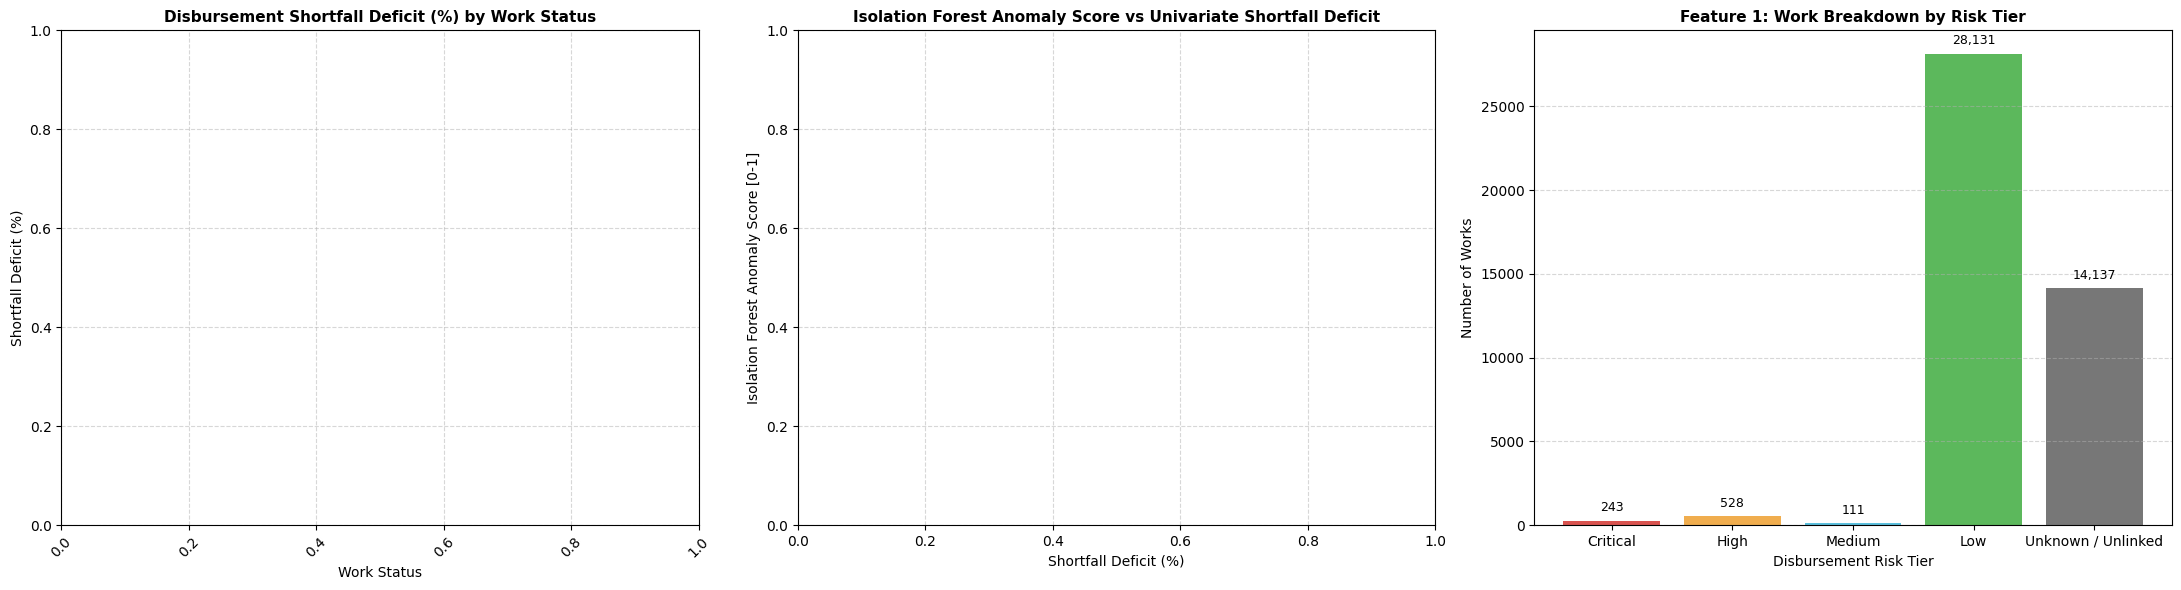

In [9]:
# Visualizations for Dashboard & ML Model Audit
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Shortfall Deficit % Distribution by Work Status
linked_df = df[df["coverage_flag"] == "linked"].copy()

sns.boxplot(
    data=linked_df,
    x="work_status",
    y="shortfall_deficit_pct",
    ax=axes[0],
    palette="Reds"
)
axes[0].set_title("Disbursement Shortfall Deficit (%) by Work Status", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Work Status", fontsize=10)
axes[0].set_ylabel("Shortfall Deficit (%)", fontsize=10)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2: Isolation Forest Anomaly Score vs Shortfall Deficit %
sns.scatterplot(
    data=linked_df,
    x="shortfall_deficit_pct",
    y="iforest_anomaly_score",
    hue="disbursement_risk_tier",
    palette={"Critical": "#d9534f", "High": "#f0ad4e", "Medium": "#5bc0de", "Low": "#5cb85c"},
    ax=axes[1],
    alpha=0.7
)
axes[1].set_title("Isolation Forest Anomaly Score vs Univariate Shortfall Deficit", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Shortfall Deficit (%)", fontsize=10)
axes[1].set_ylabel("Isolation Forest Anomaly Score [0-1]", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

# Plot 3: Risk Tier Distribution Count
tier_order = ["Critical", "High", "Medium", "Low", "Unknown / Unlinked"]
tier_counts = df["disbursement_risk_tier"].value_counts().reindex(tier_order).fillna(0)

bars = axes[2].bar(tier_counts.index, tier_counts.values, color=["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c", "#777777"])
axes[2].set_title("Feature 1: Work Breakdown by Risk Tier", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Disbursement Risk Tier", fontsize=10)
axes[2].set_ylabel("Number of Works", fontsize=10)
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, yval + 400, f"{int(yval):,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# Save plot
plot_path = OUTPUT_DIR / "feature1_shortfall_distribution.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
logger.info("Saved visualization plot to: %s", plot_path)
plt.show()


In [10]:
# Artifact Export & Fact-Table Update
import json
from datetime import datetime, timezone

# 1. Export Feature 1 Enriched Dataset
f1_csv_path = OUTPUT_DIR / "feature1_fact_work_disbursement_risk.csv"
f1_parquet_path = OUTPUT_DIR / "feature1_fact_work_disbursement_risk.parquet"

df.to_csv(f1_csv_path, index=False)
try:
    df.to_parquet(f1_parquet_path, index=False)
except Exception as e:
    logger.warning("Could not export parquet to %s: %s", f1_parquet_path, e)

# 2. Export Critical & High Risk Worklist
worklist_path = OUTPUT_DIR / "feature1_disbursement_risk_worklist.csv"
high_risk_worklist = df[df["disbursement_risk_tier"].isin(["Critical", "High"])].sort_values(
    by=["disbursement_risk_score", "shortfall_deficit_pct"],
    ascending=[False, False]
)
high_risk_worklist.to_csv(worklist_path, index=False)
logger.info("Exported high-risk worklist (%d rows) to: %s", len(high_risk_worklist), worklist_path)

# 3. Export Shared Preprocessing Updated Fact Table
shared_f1_csv = SHARED_ARTIFACT_DIR / "fact_work_feature1.csv"
shared_f1_parquet = SHARED_ARTIFACT_DIR / "fact_work_feature1.parquet"

df.to_csv(shared_f1_csv, index=False)
try:
    df.to_parquet(shared_f1_parquet, index=False)
    logger.info("Exported canonical updated table to: %s", shared_f1_parquet)
except Exception as e:
    logger.warning("Could not export canonical parquet: %s", e)

# 4. Save Exact Required Run Metadata JSON
unknown_mask = df["coverage_flag"].eq("disbursement_unknown")
linked_mask = df["coverage_flag"].isin(["linked_final", "linked_tranche"])
mps_with_linked = set(df.loc[linked_mask, "mp_key"].dropna().unique())
all_mps = set(df["mp_key"].dropna().unique())

metadata = {
    "feature_name": "Feature 1: Fund Disbursement Shortfall & Completion Integrity Score (with Isolation Forest ML)",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "total_work_rows": int(len(df)),
    "linked_work_rows": int(linked_mask.sum()),
    "unknown_work_rows": int(unknown_mask.sum()),
    "unknown_rows_with_nonnull_risk_score": int(df.loc[unknown_mask, "disbursement_risk_score"].notna().sum()),
    "unknown_rows_with_nonunknown_tier": int((df.loc[unknown_mask, "disbursement_risk_tier"] != "Unknown / Unlinked").sum()),
    "mps_with_zero_linked_rows": int(len(all_mps - mps_with_linked)),
    "split_method": "chronological_date_split",
    "partition_counts": {k: int(v) for k, v in df["model_split"].value_counts().items()},
    "peer_reference_version": "v2.1_training_partition_source_aware",
    "peer_fallback_counts": {k: int(v) for k, v in df["peer_reference_level"].value_counts().items()},
    "status_mapping_unknown_count": int(df["status_mapping_unknown"].sum()),
    "isolation_forest": {
        "n_estimators": 100,
        "contamination": 0.03,
        "seed_list": [42, 52, 62, 72, 82],
        "ensemble_score": "mean_of_per_seed_training_quantile_normalized_scores",
        "features_used": [
            "shortfall_deficit_pct_tranche",
            "shortfall_deficit_pct_final",
            "tranche_count_clean",
            "days_sanction_to_last_tranche",
            "work_status_ordinal",
            "log_sanction_amount"
        ],
        "model_artifact": str(OUTPUT_DIR / "feature1_isolation_forest.joblib")
    }
}

metadata_path = OUTPUT_DIR / "feature1_run_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

logger.info("Feature 1 execution finished successfully! Metadata saved to: %s", metadata_path)


